
# Triadic Cell Notebook v38
## Resoluteness-breath runtime

This notebook implements **breath without moving**.

The active branch set stays fixed.
Breathing happens by changing the **resoluteness** of the same inverse-query vacuum and request shape.

- low $\rho$ = soft, broad, exploratory cavity
- high $\rho$ = tight, crisp, decisive cavity

Main outputs:
- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `rho_summary`
- `rho_trace_df`


In [1]:

from __future__ import annotations
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)
rng = np.random.default_rng(42)
print("Environment ready.")


Environment ready.


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [[0.95,0.15,0.10,0.20,0.30,0.10],[0.70,0.25,0.45,0.30,0.45,0.20],[0.55,0.20,0.60,0.25,0.70,0.35]],
    [[0.10,0.95,0.15,0.25,0.10,0.30],[0.25,0.72,0.25,0.50,0.25,0.45],[0.20,0.58,0.30,0.70,0.30,0.72]],
    [[0.20,0.10,0.95,0.15,0.25,0.12],[0.45,0.25,0.75,0.30,0.42,0.22],[0.62,0.22,0.55,0.25,0.72,0.30]],
    [[0.15,0.22,0.18,0.95,0.12,0.35],[0.28,0.42,0.25,0.75,0.22,0.58],[0.35,0.72,0.30,0.60,0.25,0.78]],
], dtype=float)

def normalize01(x): return np.clip(x, 0.0, 1.0)

def cosine_similarity(a, b):
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape, local_mold, alpha=0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape","bridge_value","declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936


In [3]:

raw_basis = np.array([
    [1.0,0.0,0.6,0.2,0.0,0.3],
    [0.2,1.0,0.0,0.6,0.2,0.0],
    [0.0,0.2,1.0,0.0,0.6,0.2],
    [0.6,0.0,0.2,1.0,0.0,0.6],
    [0.0,0.6,0.2,0.0,1.0,0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)
U = np.stack(basis, axis=0)
U.shape


(5, 6)

In [4]:

QUERY_MODES = ["existing","partial","noisy","ambiguous","inverse_hint"]
QUERY_WEIGHTS = np.array([0.28,0.28,0.18,0.16,0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls, mode):
    target = chains[cls][0].copy()
    q = target.copy()
    if mode == "existing":
        q += rng.normal(0.0, 0.015, size=q.shape[0])
    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.45
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])
    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])
    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.56 * target + 0.44 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])
    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0
    return normalize01(q)


In [5]:

def directional_coeffs(x): return U @ x
def reconstruct_from_coeffs(c): return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query, target):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)
    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)
    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)
    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)
    return {
        "R": R, "M": M, "E": E,
        "aligned_ratio": float(aligned_energy / total_energy),
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
    }

def triadic_evaluate(query, cls):
    s0, _, _ = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)
    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)
    bridge_energy = 0.35 * split["missing_ratio"] + 0.20 * split["excess_ratio"] + 0.45 * (1.0 - retrieve_fit)
    declaration_score = (
        0.60 * retrieve_fit + 0.35 * split["aligned_ratio"]
        - 0.95 * split["missing_ratio"] - 0.45 * split["excess_ratio"] - 0.45 * bridge_energy
    )
    return {
        "class": cls, "retrieve_fit": float(retrieve_fit), "bridge_energy": float(bridge_energy),
        "declaration_score": float(declaration_score), "R": split["R"], "M": split["M"], "E": split["E"],
        "declared_value": projected2,
    }

def triadic_query(query):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin

def produce_fields_for_class(query, cls):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)
    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])
    retrieve_mask = normalize01(ev["R"])
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]
    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total
    return {
        "predicted_class": cls, "margin": margin, "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"], "declaration_score": ev["declaration_score"],
        "retrieve_mask": retrieve_mask, "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask, "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"])


In [6]:

obs_dim = 3
OBS_W = np.array([
    [0.80,0.10,0.35,0.05,0.20,0.10],
    [0.10,0.75,0.10,0.30,0.05,0.25],
    [0.20,0.10,0.55,0.10,0.45,0.20],
], dtype=float)

def observable_from_declared(declared_value):
    return normalize01(OBS_W @ declared_value)

def build_inverse_vacuum(query, fields):
    inv_query = 1.0 - query
    contradiction = fields["contradiction_mask"]
    return normalize01(0.75 * inv_query + 0.25 * contradiction)

def apply_resoluteness(x, rho, eps=1e-8):
    return normalize01(np.clip(x, eps, 1.0) ** rho)

def build_request_shape(query, fields, rho=1.0, top_k=1):
    pred_obs = observable_from_declared(fields["declared_value"])
    vacuum = build_inverse_vacuum(query, fields)
    vacuum_obs = normalize01(OBS_W @ vacuum)
    vacuum_obs_r = apply_resoluteness(vacuum_obs, rho)
    need_obs_r = apply_resoluteness(1.0 - pred_obs, rho)
    request_scores = vacuum_obs_r * need_obs_r
    idx = np.argsort(request_scores)[-top_k:]
    mask = np.zeros(obs_dim, dtype=float)
    mask[idx] = 1.0
    tol_lo, tol_hi = 0.08, 0.30
    tolerance = tol_hi * (1.0 - min(max((rho - 0.35) / 1.10, 0.0), 1.0)) + tol_lo * min(max((rho - 0.35) / 1.10, 0.0), 1.0)
    return {
        "mask": mask,
        "expected_profile": pred_obs,
        "vacuum_obs": vacuum_obs_r,
        "tolerance": float(tolerance),
        "priority": float(vacuum_obs_r.mean()),
        "rho": float(rho),
    }

def provider_pull(true_cls, request_shape):
    full_obs = observable_from_declared(chains[true_cls][2])
    mask = request_shape["mask"]
    packet = full_obs * mask + rng.normal(0.0, 0.02, size=full_obs.shape[0]) * mask
    return normalize01(packet)

def branch_entropy_from_scores(scores):
    x = np.array(scores, dtype=float)
    z = x - np.max(x)
    e = np.exp(z)
    p = e / (np.sum(e) + 1e-8)
    return float(-np.sum(p * np.log(p + 1e-8)))

DIRECT_THRESHOLD = 0.985
SHAPE_THRESHOLD = 0.78

def direct_lookup_score(query):
    scores = [(cls, cosine_similarity(query, chains[cls][0])) for cls in range(n_classes)]
    scores.sort(key=lambda x: x[1], reverse=True)
    cls, score = scores[0]
    return {"class": cls, "score": float(score), "hit": score >= DIRECT_THRESHOLD}

def shape_lookup_score(query):
    best, _, margin = triadic_query(query)
    return {"class": best["class"], "score": float(best["retrieve_fit"]), "margin": float(margin), "hit": best["retrieve_fit"] >= SHAPE_THRESHOLD}


In [7]:

def seat_gain(before_fields, after_fields):
    before_missing = float(before_fields["missing_mask"].mean())
    after_missing = float(after_fields["missing_mask"].mean())
    before_contra = float(before_fields["contradiction_mask"].mean())
    after_contra = float(after_fields["contradiction_mask"].mean())
    before_decl = float(before_fields["declaration_score"])
    after_decl = float(after_fields["declaration_score"])
    return float(0.60 * (before_missing - after_missing) - 0.25 * (after_contra - before_contra) + 0.15 * (after_decl - before_decl))

def v37_like_runtime(query, true_cls, cycles=4, beam_width=3, exhale_steps=2, step_size=0.45, damping=0.85):
    direct = direct_lookup_score(query)
    shape = shape_lookup_score(query)
    seed_scores = {}
    seed_scores[direct["class"]] = seed_scores.get(direct["class"], 0.0) + 0.60 * direct["score"]
    seed_scores[shape["class"]] = seed_scores.get(shape["class"], 0.0) + 0.50 * shape["score"]
    decl_sorted = sorted([(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)], key=lambda x: x[1], reverse=True)[:beam_width]
    for cls, score in decl_sorted:
        seed_scores[cls] = seed_scores.get(cls, 0.0) + 0.40 * score
    beam = [{"cls": cls, "query": query.copy()} for cls, _ in sorted(seed_scores.items(), key=lambda x: x[1], reverse=True)[:beam_width]]

    for _ in range(cycles):
        scored = []
        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]
            for _ in range(exhale_steps):
                f_before = produce_fields_for_class(q, cls)
                request = build_request_shape(q, f_before, rho=1.0, top_k=1)
                packet = provider_pull(true_cls, request)
                packet_back = normalize01(request["mask"] @ OBS_W)
                vacuum = build_inverse_vacuum(q, f_before)
                vacuum_push = normalize01(0.5 * packet_back + 0.5 * vacuum)
                update = step_size * (0.6 * f_before["signed_correction"] + 0.4 * vacuum_push)
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))
            f_before = produce_fields_for_class(q, cls)
            request = build_request_shape(q, f_before, rho=1.0, top_k=1)
            packet = provider_pull(true_cls, request)
            pred_obs = observable_from_declared(f_before["declared_value"])
            obs_misfit = float(np.mean(np.abs(request["mask"] * (packet - pred_obs))))
            packet_back = normalize01(request["mask"] @ OBS_W)
            vacuum = build_inverse_vacuum(q, f_before)
            vacuum_push = normalize01(0.5 * packet_back + 0.5 * vacuum)
            q_test = normalize01(q + 0.25 * (0.6 * f_before["signed_correction"] + 0.4 * vacuum_push))
            f_after = produce_fields_for_class(q_test, cls)
            sg = seat_gain(f_before, f_after)
            energy = (
                0.85 * float(f_before["missing_mask"].mean())
                + 0.55 * float(f_before["contradiction_mask"].mean())
                - 0.75 * float(f_before["declaration_score"])
                - 0.25 * float(f_before["retrieve_mask"].mean())
                + 0.75 * obs_misfit
                - 0.55 * sg
            )
            scored.append({"cls": cls, "query": q.copy(), "energy": float(energy)})
        beam = sorted(scored, key=lambda x: x["energy"])[:beam_width]

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"])
    return {"predicted_class": final_fields["predicted_class"], "fields": final_fields}

def rho_from_field(mean_seat_gain, mean_obs_misfit, winner_margin, entropy):
    raw = 4.0 * mean_seat_gain - 3.0 * mean_obs_misfit + 2.0 * winner_margin - 1.5 * entropy
    sig = 1.0 / (1.0 + np.exp(-raw))
    return float(0.35 + 1.10 * sig)

def v38_resolute_runtime(query, true_cls, cycles=4, beam_width=3, exhale_steps=2, step_size=0.45, damping=0.85):
    direct = direct_lookup_score(query)
    shape = shape_lookup_score(query)
    seed_scores = {}
    seed_scores[direct["class"]] = seed_scores.get(direct["class"], 0.0) + 0.60 * direct["score"]
    seed_scores[shape["class"]] = seed_scores.get(shape["class"], 0.0) + 0.50 * shape["score"]
    decl_sorted = sorted([(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)], key=lambda x: x[1], reverse=True)[:beam_width]
    for cls, score in decl_sorted:
        seed_scores[cls] = seed_scores.get(cls, 0.0) + 0.40 * score
    fixed_classes = [cls for cls, _ in sorted(seed_scores.items(), key=lambda x: x[1], reverse=True)[:beam_width]]
    beam = {cls: query.copy() for cls in fixed_classes}
    rho = 1.0
    trace_rows = []

    for cycle in range(cycles):
        cycle_energies, cycle_seat_gains, cycle_misfits = [], [], []

        for cls in fixed_classes:
            q = beam[cls].copy()
            last_request = None
            last_packet = None
            last_obs_misfit = 0.0
            sg = 0.0

            for _ in range(exhale_steps):
                f_before = produce_fields_for_class(q, cls)
                request = build_request_shape(q, f_before, rho=rho, top_k=1)
                packet = provider_pull(true_cls, request)
                pred_obs = observable_from_declared(f_before["declared_value"])
                last_obs_misfit = float(np.mean(np.abs(request["mask"] * (packet - pred_obs))))
                packet_back = normalize01(request["mask"] @ OBS_W)
                vacuum = build_inverse_vacuum(q, f_before)
                vacuum_push = normalize01(0.5 * packet_back + 0.5 * apply_resoluteness(vacuum, rho))
                update = step_size * (0.6 * f_before["signed_correction"] + 0.4 * vacuum_push)
                q_new = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))
                f_after = produce_fields_for_class(q_new, cls)
                sg = seat_gain(f_before, f_after)
                q = q_new
                last_request, last_packet = request, packet

            beam[cls] = q
            f_end = produce_fields_for_class(q, cls)
            energy = (
                0.85 * float(f_end["missing_mask"].mean())
                + 0.55 * float(f_end["contradiction_mask"].mean())
                - 0.75 * float(f_end["declaration_score"])
                - 0.25 * float(f_end["retrieve_mask"].mean())
                + 0.75 * last_obs_misfit
                - 0.55 * sg
            )
            cycle_energies.append((cls, float(energy), float(f_end["margin"])))
            cycle_seat_gains.append(float(sg))
            cycle_misfits.append(float(last_obs_misfit))

            trace_rows.append({
                "cycle": cycle, "class": cls, "rho": float(rho), "energy": float(energy), "seat_gain": float(sg),
                "missing_mass": float(f_end["missing_mask"].mean()), "retrieve_mass": float(f_end["retrieve_mask"].mean()),
                "contradiction_mass": float(f_end["contradiction_mask"].mean()), "declaration_score": float(f_end["declaration_score"]),
                "obs_misfit": float(last_obs_misfit),
                "request_mask_0": float(last_request["mask"][0]), "request_mask_1": float(last_request["mask"][1]), "request_mask_2": float(last_request["mask"][2]),
                "vacuum_obs_0": float(last_request["vacuum_obs"][0]), "vacuum_obs_1": float(last_request["vacuum_obs"][1]), "vacuum_obs_2": float(last_request["vacuum_obs"][2]),
                "tolerance": float(last_request["tolerance"]),
            })

        cycle_energies = sorted(cycle_energies, key=lambda x: x[1])
        winner_margin = float(cycle_energies[1][1] - cycle_energies[0][1]) if len(cycle_energies) > 1 else 1.0
        entropy = branch_entropy_from_scores([-e for _, e, _ in cycle_energies])
        rho = rho_from_field(float(np.mean(cycle_seat_gains)), float(np.mean(cycle_misfits)), winner_margin, entropy)

    final_scores = []
    for cls in fixed_classes:
        f = produce_fields_for_class(beam[cls], cls)
        energy = 0.85 * float(f["missing_mask"].mean()) + 0.55 * float(f["contradiction_mask"].mean()) - 0.75 * float(f["declaration_score"]) - 0.25 * float(f["retrieve_mask"].mean())
        final_scores.append((cls, float(energy)))
    final_cls = sorted(final_scores, key=lambda x: x[1])[0][0]
    final_fields = produce_fields_for_class(beam[final_cls], final_cls)
    return {"predicted_class": final_fields["predicted_class"], "fields": final_fields, "trace_df": pd.DataFrame(trace_rows), "fixed_classes": fixed_classes}


In [8]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

v37 = v37_like_runtime(q0, true_cls=example_cls)
v38 = v38_resolute_runtime(q0, true_cls=example_cls)
rho_trace_df = v38["trace_df"]

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "v37_predicted_class": v37["predicted_class"],
    "v38_predicted_class": v38["predicted_class"],
    "v37_missing_mass": float(v37["fields"]["missing_mask"].mean()),
    "v38_missing_mass": float(v38["fields"]["missing_mask"].mean()),
    "v37_retrieve_mass": float(v37["fields"]["retrieve_mask"].mean()),
    "v38_retrieve_mass": float(v38["fields"]["retrieve_mask"].mean()),
    "fixed_classes": str(v38["fixed_classes"]),
}])
single_example


,true_class,query_mode,v37_predicted_class,v38_predicted_class,v37_missing_mass,v38_missing_mass,v37_retrieve_mass,v38_retrieve_mass,fixed_classes
0,1,partial,3,3,0.341696,0.329459,0.658304,0.670541,"[3, 2, 0]"


In [9]:

rho_trace_df.head(12)


,cycle,class,rho,energy,seat_gain,missing_mass,retrieve_mass,contradiction_mass,declaration_score,obs_misfit,request_mask_0,request_mask_1,request_mask_2,vacuum_obs_0,vacuum_obs_1,vacuum_obs_2,tolerance
0,0,3,1.000000,0.196670,0.022315,0.510000,0.490000,0.024331,0.165064,0.011146,1.0,0.0,0.0,1.000000,1.000000,1.000000,0.170000
1,0,2,1.000000,0.558891,0.034678,0.485504,0.514496,0.088797,-0.175306,0.151455,0.0,1.0,0.0,1.000000,1.000000,1.000000,0.170000
2,0,0,1.000000,0.846327,0.054225,0.687730,0.312270,0.126398,-0.250978,0.149193,0.0,1.0,0.0,1.000000,1.000000,1.000000,0.170000
3,1,3,0.638516,0.044767,0.027644,0.452071,0.547929,0.027394,0.301517,0.031685,1.0,0.0,0.0,1.000000,0.972334,1.000000,0.242297
4,1,2,0.638516,0.360782,0.030491,0.422986,0.577014,0.093905,0.009739,0.157231,0.0,1.0,0.0,1.000000,0.995736,1.000000,0.242297
5,1,0,0.638516,0.563995,0.049465,0.565112,0.434888,0.128033,-0.052556,0.146323,0.0,1.0,0.0,1.000000,0.999438,1.000000,0.242297
6,2,3,0.609986,-0.093700,0.024430,0.384760,0.615240,0.033500,0.400790,0.038224,1.0,0.0,0.0,0.975717,0.943268,0.979732,0.248003
7,2,2,0.609986,0.212854,0.019445,0.378996,0.621004,0.098830,0.149225,0.152287,0.0,1.0,0.0,0.981222,0.970896,0.972546,0.248003
8,2,0,0.609986,0.314874,0.047879,0.441959,0.558041,0.129662,0.098232,0.143217,0.0,1.0,0.0,0.971640,0.972846,1.000000,0.248003
9,3,3,0.600248,-0.192055,0.018283,0.329459,0.670541,0.053105,0.464962,0.033479,1.0,0.0,0.0,0.955781,0.917593,0.960817,0.249950


In [10]:

rows_compare = []
for true_cls in range(n_classes):
    for _ in range(350):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(true_cls, mode)
        first = produce_fields_best(q)
        v37 = v37_like_runtime(q, true_cls=true_cls)
        v38 = v38_resolute_runtime(q, true_cls=true_cls)
        rows_compare.append({
            "true_class": true_cls,
            "query_mode": mode,
            "first_correct": int(first["predicted_class"] == true_cls),
            "v37_correct": int(v37["predicted_class"] == true_cls),
            "v38_correct": int(v38["predicted_class"] == true_cls),
            "first_missing_mass": float(first["missing_mask"].mean()),
            "v37_missing_mass": float(v37["fields"]["missing_mask"].mean()),
            "v38_missing_mass": float(v38["fields"]["missing_mask"].mean()),
            "first_retrieve_mass": float(first["retrieve_mask"].mean()),
            "v37_retrieve_mass": float(v37["fields"]["retrieve_mask"].mean()),
            "v38_retrieve_mass": float(v38["fields"]["retrieve_mask"].mean()),
        })
compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,v37_correct,v38_correct,first_missing_mass,v37_missing_mass,v38_missing_mass,first_retrieve_mass,v37_retrieve_mass,v38_retrieve_mass
0,0,existing,1,1,1,0.047715,0.000000,0.000000,0.952285,1.000000,1.000000
1,0,noisy,1,1,1,0.438561,0.090312,0.098518,0.561439,0.909688,0.901482
2,0,existing,1,1,1,0.032296,0.000000,0.000000,0.967704,1.000000,1.000000
3,0,noisy,1,1,1,0.080009,0.000000,0.000000,0.919990,1.000000,1.000000
4,0,inverse_hint,1,1,1,0.269007,0.240986,0.240214,0.730993,0.759014,0.759786


In [11]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "v37_accuracy": float(compare_df["v37_correct"].mean()),
    "v38_accuracy": float(compare_df["v38_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "v37_missing_mass": float(compare_df["v37_missing_mass"].mean()),
    "v38_missing_mass": float(compare_df["v38_missing_mass"].mean()),
}])
compare_summary


,first_pass_accuracy,v37_accuracy,v38_accuracy,first_pass_missing_mass,v37_missing_mass,v38_missing_mass
0,0.830714,0.825714,0.820714,0.297178,0.103985,0.099743


In [12]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct","v37_correct","v38_correct",
        "first_missing_mass","v37_missing_mass","v38_missing_mass",
        "first_retrieve_mass","v37_retrieve_mass","v38_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)
by_mode_compare["v38_vs_first_gain"] = by_mode_compare["v38_correct"] - by_mode_compare["first_correct"]
by_mode_compare["v38_vs_v37_gain"] = by_mode_compare["v38_correct"] - by_mode_compare["v37_correct"]
by_mode_compare["v38_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["v38_missing_mass"]
by_mode_compare = by_mode_compare.sort_values("v38_vs_first_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,v37_correct,v38_correct,first_missing_mass,v37_missing_mass,v38_missing_mass,first_retrieve_mass,v37_retrieve_mass,v38_retrieve_mass,v38_vs_first_gain,v38_vs_v37_gain,v38_missing_drop
1,existing,1.000000,1.000000,1.000000,0.068196,0.002991,0.003170,0.925428,0.952382,0.952203,0.000000,0.000000,0.065027
3,noisy,1.000000,1.000000,1.000000,0.189084,0.045231,0.046647,0.810222,0.941574,0.940158,0.000000,0.000000,0.142437
4,partial,0.565116,0.562791,0.562791,0.561673,0.202602,0.196995,0.437939,0.793134,0.798741,-0.002326,0.000000,0.364679
2,inverse_hint,0.734694,0.714286,0.700680,0.273097,0.131213,0.120203,0.714432,0.834773,0.845782,-0.034014,-0.013605,0.152893
0,ambiguous,0.949309,0.935484,0.912442,0.295137,0.125443,0.114779,0.697183,0.835386,0.848354,-0.036866,-0.023041,0.180358


In [13]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()
partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_v37_accuracy": float(partial_df["v37_correct"].mean()),
    "partial_v38_accuracy": float(partial_df["v38_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_v37_missing_mass": float(partial_df["v37_missing_mass"].mean()),
    "partial_v38_missing_mass": float(partial_df["v38_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_v37_retrieve_mass": float(partial_df["v37_retrieve_mass"].mean()),
    "partial_v38_retrieve_mass": float(partial_df["v38_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_v37_accuracy,partial_v38_accuracy,partial_first_missing_mass,partial_v37_missing_mass,partial_v38_missing_mass,partial_first_retrieve_mass,partial_v37_retrieve_mass,partial_v38_retrieve_mass
0,0.565116,0.562791,0.562791,0.561673,0.202602,0.196995,0.437939,0.793134,0.798741


In [14]:

rho_summary = pd.DataFrame([{
    "mean_rho": float(rho_trace_df["rho"].mean()) if len(rho_trace_df) else np.nan,
    "min_rho": float(rho_trace_df["rho"].min()) if len(rho_trace_df) else np.nan,
    "max_rho": float(rho_trace_df["rho"].max()) if len(rho_trace_df) else np.nan,
    "mean_seat_gain": float(rho_trace_df["seat_gain"].mean()) if len(rho_trace_df) else np.nan,
    "mean_obs_misfit": float(rho_trace_df["obs_misfit"].mean()) if len(rho_trace_df) else np.nan,
    "mean_tolerance": float(rho_trace_df["tolerance"].mean()) if len(rho_trace_df) else np.nan,
}])
rho_summary


,mean_rho,min_rho,max_rho,mean_seat_gain,mean_obs_misfit,mean_tolerance
0,0.712187,0.600248,1.0,0.030962,0.109545,0.227563


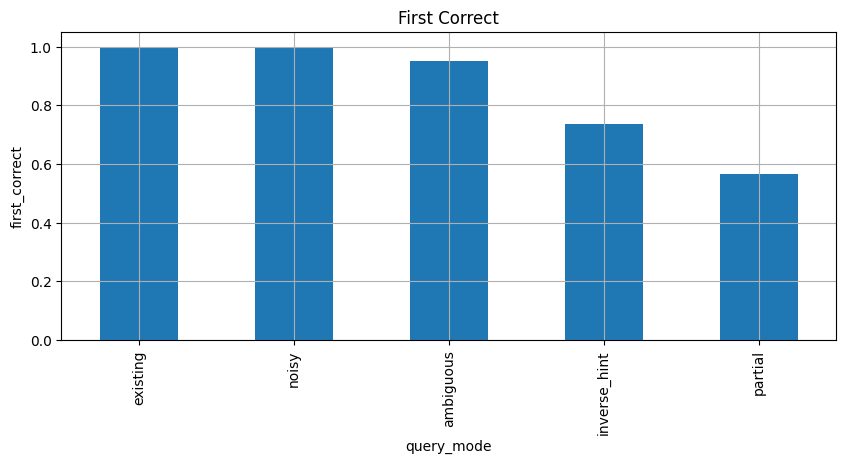

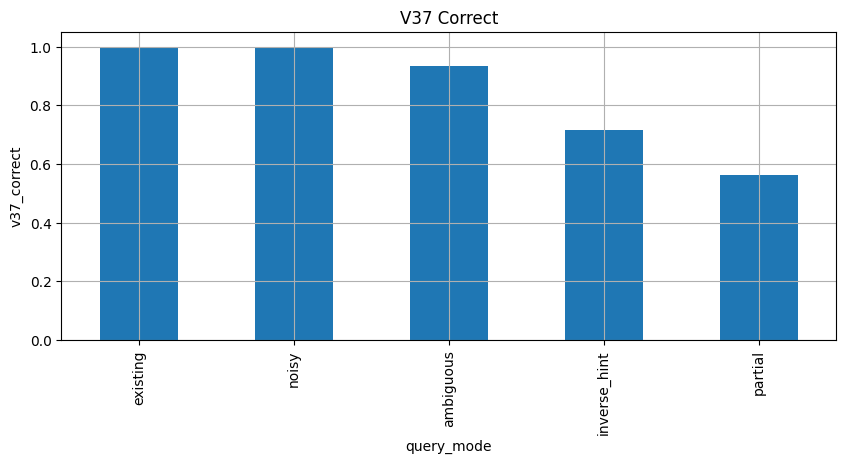

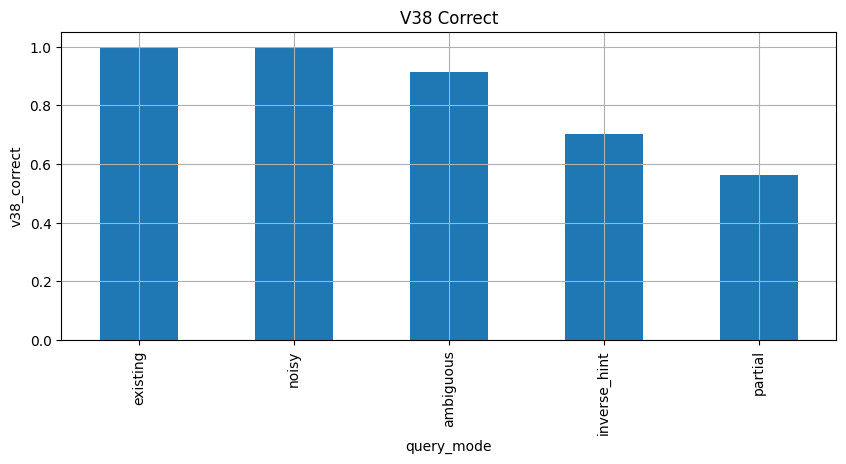

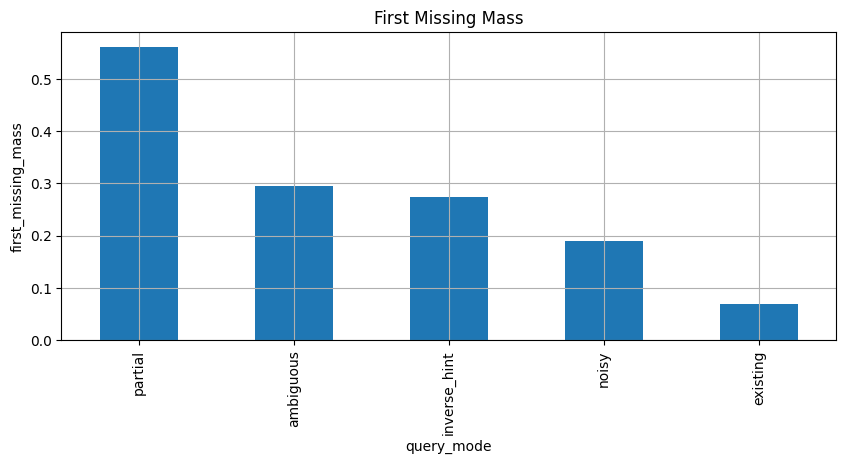

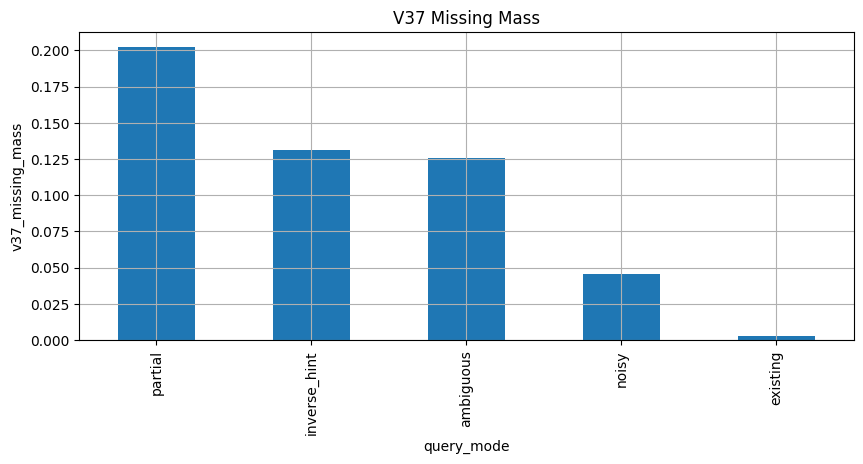

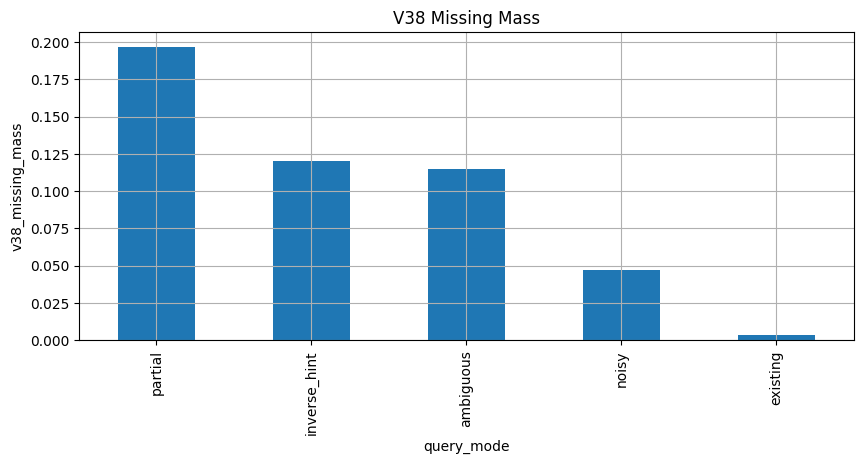

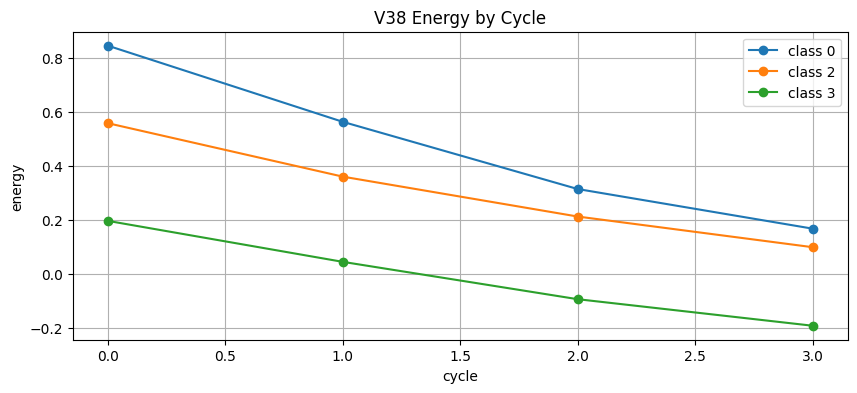

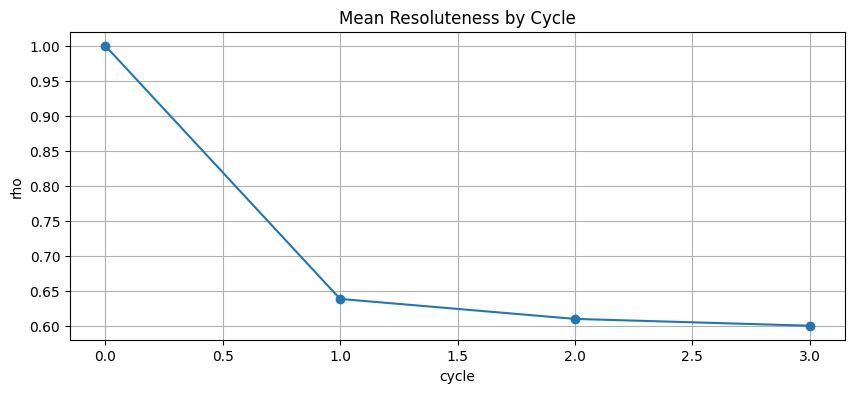

In [15]:

metrics = ["first_correct","v37_correct","v38_correct","first_missing_mass","v37_missing_mass","v38_missing_mass"]
for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()

if len(rho_trace_df):
    plt.figure(figsize=(10, 4))
    for cls in sorted(rho_trace_df["class"].unique()):
        df = rho_trace_df[rho_trace_df["class"] == cls]
        plt.plot(df["cycle"], df["energy"], marker="o", label=f"class {cls}")
    plt.title("V38 Energy by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("energy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(rho_trace_df.groupby("cycle")["rho"].mean(), marker="o")
    plt.title("Mean Resoluteness by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("rho")
    plt.show()



## Practical readout

This notebook tests the law directly:

- the fixed branch set stays fixed
- the vacuum and request shape become more or less resolute
- tolerance breathes inversely with resoluteness

Read first:
- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `rho_summary`
- `rho_trace_df`
